# bayes_poisson smoke test

This notebook provides a quick functional test for the `bayes_poisson` model.

If the model is not available, build extensions first:

```bash
python setup.py build_ext --inplace
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ssms.basic_simulators.simulator import simulator, OMISSION_SENTINEL
from ssms.config import ModelConfigBuilder

In [2]:
try:
    cfg = ModelConfigBuilder.from_model("bayes_poisson")
except Exception as exc:
    raise RuntimeError(
        "`bayes_poisson` is not available. Build cssm extensions first."
    ) from exc

cfg["name"], cfg["params"], cfg["choices"]

('bayes_poisson',
 ['signal1', 'signal2', 'noise', 't', 'entropy', 'step'],
 [0, 1])

In [3]:
# Single-trial test
theta = {
    "signal1": 2,
    "signal2": 0,
    "noise": .3,
    "t": 0.15,
    "entropy": 0.20,
    "step": 0.01,
}

out = simulator(
    model="bayes_poisson",
    theta=theta,
    n_samples=50000,
    random_state=2026,
    return_option="full",
)

out.keys()

dict_keys(['rts', 'choices', 'metadata', 'choice_p', 'choice_p_no_omission', 'omission_p', 'nogo_p', 'go_p', 'binned_128', 'binned_256'])

In [4]:
rts = np.squeeze(out["rts"])
choices = np.squeeze(out["choices"])
valid = rts != OMISSION_SENTINEL

summary = {
    "n_samples": int(out["metadata"]["n_samples"]),
    "valid_fraction": float(np.mean(valid)),
    "mean_rt_valid": float(np.mean(rts[valid])) if np.any(valid) else np.nan,
    "choice_counts": {
        int(c): int(np.sum(choices == c))
        for c in np.unique(choices)
    },
    "choice_p": out["choice_p"],
    "omission_p": out["omission_p"],
}
summary

{'n_samples': 50000,
 'valid_fraction': 1.0,
 'mean_rt_valid': 2.0884575843811035,
 'choice_counts': {0: 24712, 1: 25288},
 'choice_p': array([[0.49424, 0.50576]]),
 'omission_p': array([[0.]])}

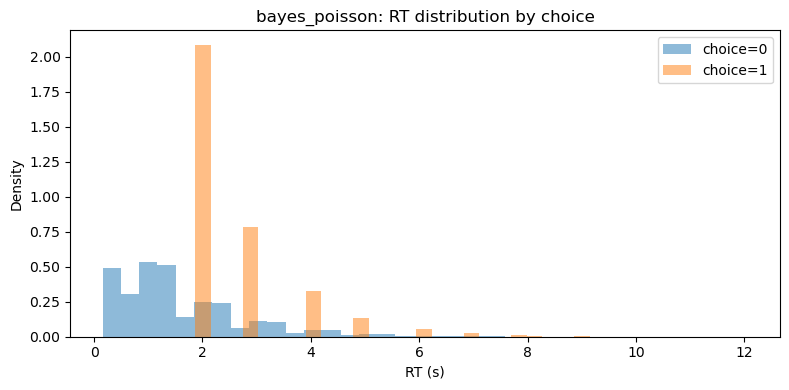

In [5]:
# Visualize valid RT distributions by decoded choice
plt.figure(figsize=(8, 4))
for c in sorted(np.unique(choices)):
    mask = (choices == c) & valid
    if np.any(mask):
        plt.hist(rts[mask], bins=35, alpha=0.5, density=True, label=f"choice={int(c)}")

plt.title("bayes_poisson: RT distribution by choice")
plt.xlabel("RT (s)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Multi-trial vectorized parameter test
theta_multi = {
    "signal1": np.array([4.0, 4.0, 4.0], dtype=np.float32),
    "signal2": np.array([1.5, 2.5, 3.5], dtype=np.float32),
    "noise": np.array([3.0, 3.0, 3.0], dtype=np.float32),
    "t": np.array([0.12, 0.15, 0.18], dtype=np.float32),
    "entropy": np.array([0.20, 0.20, 0.20], dtype=np.float32),
    "step": np.array([0.01, 0.01, 0.01], dtype=np.float32),
}

out_multi = simulator(
    model="bayes_poisson",
    theta=theta_multi,
    n_samples=2000,
    random_state=2026,
    return_option="full",
)

out_multi["metadata"], out_multi["choice_p"], out_multi["omission_p"]

({'simulator': 'bayes_poisson',
  'possible_choices': [np.int32(0), np.int32(1)],
  'n_samples': 2000,
  'n_trials': 3,
  'max_t': 20.0,
  'delta_t': 0.0010000000474974513,
  'signal': array([[4. , 1.5],
         [4. , 2.5],
         [4. , 3.5]], dtype=float32),
  'noise': array([[3., 3.],
         [3., 3.],
         [3., 3.]], dtype=float32),
  't': array([[0.12],
         [0.15],
         [0.18]], dtype=float32),
  'deadline': array([999., 999., 999.], dtype=float32),
  's': array([[1., 1.],
         [1., 1.],
         [1., 1.]], dtype=float32),
  'entropy_threshold': array([[0.2],
         [0.2],
         [0.2]], dtype=float32),
  'time_step': array([[0.01],
         [0.01],
         [0.01]], dtype=float32),
  'prior': array([[0.5, 0.5],
         [0.5, 0.5],
         [0.5, 0.5]], dtype=float32),
  'signal0': array([4., 4., 4.], dtype=float32),
  'signal1': array([1.5, 2.5, 3.5], dtype=float32),
  'noise0': array([3., 3., 3.], dtype=float32),
  'noise1': array([3., 3., 3.], dtype=flo